In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

For better understanding and intution refer to the video on PCA by StatQuest

In [5]:
# Implementing PCA in ML and understanding its importance

In [6]:
# In simple words according to me PCA basically is a method which is used to use the principle axis , important features

In [7]:
# Another useful thing which I think is the best is we can visualize n higher dimensional data using PCA 

In [8]:
# We use the eigen vectors for this which is calculated from the cov matrix

In [9]:
# Intution : 
'''
Dimensionality Reduction (PCA)
In data science, Principal Component Analysis (PCA) uses eigenvectors to simplify massive datasets. 
The Use: If you have 1,000 different variables, the eigenvectors of your data's covariance matrix 
point in the directions where the data varies the most.
Why it helps: You can ignore directions with tiny eigenvalues (low variation) and keep only the "principal" directions.
 This allows you to compress images or simplify machine learning models without losing critical information
'''

'\nDimensionality Reduction (PCA)\nIn data science, Principal Component Analysis (PCA) uses eigenvectors to simplify massive datasets. \nThe Use: If you have 1,000 different variables, the eigenvectors of your data\'s covariance matrix \npoint in the directions where the data varies the most.\nWhy it helps: You can ignore directions with tiny eigenvalues (low variation) and keep only the "principal" directions.\n This allows you to compress images or simplify machine learning models without losing critical information\n'

Refer this article for a simple explanation : https://medium.com/@piyushkashyap045/understanding-principal-component-analysis-pca-e73c7810bbab

In [10]:
# 1. Load the Data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
features = iris.feature_names

In [ ]:
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
# Visualizing the actual dataset 

df = px.data.iris() # < - - Same dataset but labelled

fig = px.scatter_3d(
                data_frame=df,
                x = 'sepal_length',
                y = 'sepal_width',
                z = 'petal_length',
                color='species',
                size='petal_width',
                symbol='species',
                opacity=0.65,
                title='3D + 1D Iris Dataset'
)

fig.show()

# Our main aim is to decompose this into 2D plot

In [13]:
# 2 Step is to standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# 3 Applying PCA , in this we select the no of principle components to be 2 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

In [15]:
# 4 Creation of the dataframe 
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
final_df = pd.concat([principal_df, pd.DataFrame(y, columns=['target'])], axis=1)

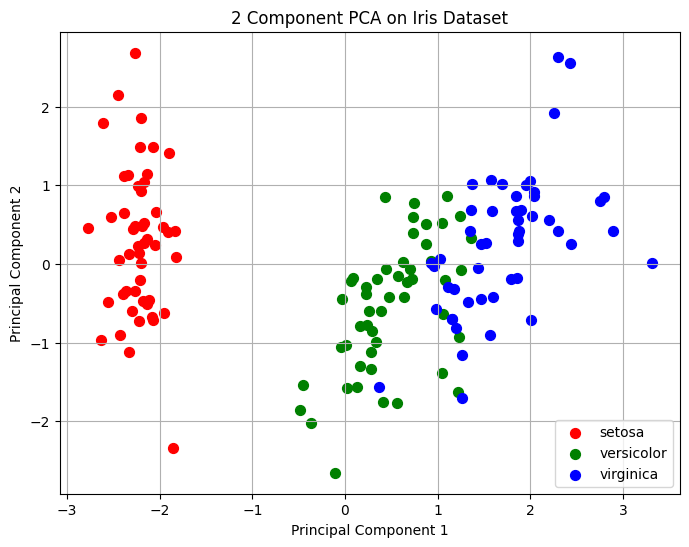

In [16]:
# 5 Visualizing the 2D axis
plt.figure(figsize=(8, 6))
# Map target numerical labels to actual names for legend
targets = [0, 1, 2]
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indices_to_keep = final_df['target'] == target
    plt.scatter(final_df.loc[indices_to_keep, 'PC1'],
                final_df.loc[indices_to_keep, 'PC2'],
                c=color,
                s=50,
                label=target_names[target])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2 Component PCA on Iris Dataset')
plt.legend()
plt.grid()
plt.show()


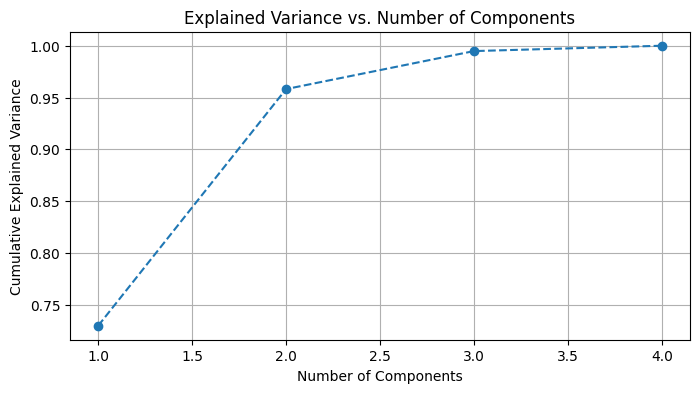

In [17]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid()
plt.show()


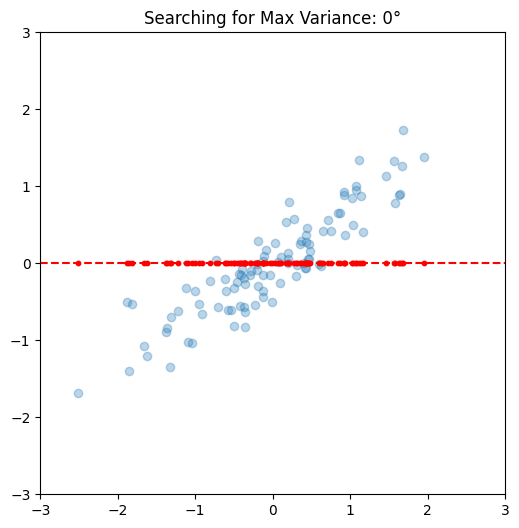

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Setup Data
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 0.7 * x + np.random.normal(0, 0.3, 100)
data = np.vstack([x, y]).T - np.mean(np.vstack([x, y]).T, axis=0)

fig, ax = plt.subplots(figsize=(6,6))

def update(angle):
    ax.clear()
    ax.scatter(data[:, 0], data[:, 1], alpha=0.3)
    
    # 2. Create the rotating hyperplane (line)
    rad = np.deg2rad(angle)
    vec = np.array([np.cos(rad), np.sin(rad)])
    
    # 3. Project points onto the line
    proj = np.outer(np.dot(data, vec), vec)
    
    # Draw line and projections
    line_limit = 3
    ax.plot([-vec[0]*line_limit, vec[0]*line_limit], [-vec[1]*line_limit, vec[1]*line_limit], 'r--')
    ax.scatter(proj[:, 0], proj[:, 1], color='red', s=10)
    ax.set_title(f"Searching for Max Variance: {angle}°")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

# 4. Save as GIF
ani = FuncAnimation(fig, update, frames=np.arange(0, 180, 2))
ani.save('pca_rotation.gif', writer='pillow')
